# Crypto Direction Classification — End-to-End ML Refresher

A complete, hands-on refresher for the **classification** workflow applied to cryptocurrency
markets. You will predict the **direction (up/down) of BTC's next 4-hour return** using
hourly OHLCV features from BTC, ETH, SOL, and BNB.

Each major section contains:
1. A teaching walkthrough with code + explanations.
2. Hands-on **exercises** with hidden solutions (click the toggle to reveal).

Treat this notebook as a workbook. Try every exercise yourself before peeking.

## 0. Setup & Imports

Standard imports plus a fixed random seed for reproducibility. Plots use a clean
seaborn style with consistent figure sizing.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

DATA_PATH = "/home/zlac116/Code/learning/ml-revision/data/crypto_hourly.parquet"
print("Setup complete. NumPy", np.__version__, "Pandas", pd.__version__)

Setup complete. NumPy 2.4.4 Pandas 2.2.3


## 0.1 Problem Framing

**Target**: For each hourly timestamp `t`, predict whether BTC's close 4 hours later is
higher than the current close:

$$ y_t = \mathbb{1}\big[ \text{close}^{BTC}_{t+4} > \text{close}^{BTC}_t \big] $$

**Why classification, not regression?**
- Direction is more robust than magnitude in noisy markets.
- Threshold tuning gives explicit control over precision/recall trade-offs.
- A binary signal maps cleanly onto downstream long/flat or long/short rules.

**Leakage rule**: Every feature at time `t` MUST be computable using only information
available **at or before** `t`. We never use future bars to engineer features. We will
sanity-check this explicitly.

## 1. Data Loading & Sanity Checks

Garbage in, garbage out. Before any modeling we verify:
1. Schema matches expectations.
2. No surprise NaNs.
3. Time index is hourly with no large gaps.
4. Symbol coverage is balanced.

Crypto data sometimes has venue outages and missing candles — finding these early prevents
silent bugs later (e.g., a stale `close` propagated forward via fillna).

In [2]:
df = pd.read_parquet(DATA_PATH)
df["ts"] = pd.to_datetime(df["ts"], utc=True)
df = df.sort_values(["symbol", "ts"]).reset_index(drop=True)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Time range:", df["ts"].min(), "->", df["ts"].max())
df.head()

Shape: (70080, 7)
Columns: ['ts', 'open', 'high', 'low', 'close', 'volume', 'symbol']
Time range: 2024-04-19 23:00:00+00:00 -> 2026-04-19 22:00:00+00:00


,ts,open,high,low,close,volume,symbol
0,2024-04-19 23:00:00+00:00,556.7,557.0,549.6,554.0,21953.020,BNB
1,2024-04-20 00:00:00+00:00,554.1,557.1,551.2,551.4,14108.411,BNB
2,2024-04-20 01:00:00+00:00,551.3,557.4,548.8,556.9,12407.915,BNB
3,2024-04-20 02:00:00+00:00,556.9,558.1,554.7,557.0,7299.961,BNB
4,2024-04-20 03:00:00+00:00,557.1,558.1,555.6,556.5,5680.975,BNB


In [3]:
print("Per-symbol row counts:")
print(df.groupby("symbol").size())
print("\nPer-symbol date span:")
print(df.groupby("symbol")["ts"].agg(["min", "max"]))
print("\nMissing values per column:")
print(df.isna().sum())

Per-symbol row counts:
symbol
BNB    17520
BTC    17520
ETH    17520
SOL    17520
dtype: int64

Per-symbol date span:
                             min                       max
symbol                                                    
BNB    2024-04-19 23:00:00+00:00 2026-04-19 22:00:00+00:00
BTC    2024-04-19 23:00:00+00:00 2026-04-19 22:00:00+00:00
ETH    2024-04-19 23:00:00+00:00 2026-04-19 22:00:00+00:00
SOL    2024-04-19 23:00:00+00:00 2026-04-19 22:00:00+00:00

Missing values per column:
ts        0
open      0
high      0
low       0
close     0
volume    0
symbol    0
dtype: int64


### Exercises — Section 1

Practice the basic data hygiene moves you should automate before any modeling.

**Exercise 1.1 — Largest time gap per symbol**

For each symbol, compute the largest gap (in hours) between consecutive `ts` values.
Return a `pd.Series` indexed by symbol, sorted descending.

In [4]:
# Your answer here
# Hint: groupby symbol, then compute diff() on ts within each group.

<details>
<summary>💡 Click to reveal solution</summary>

```python
gaps_per_symbol = (
    df.sort_values(["symbol", "ts"])
      .groupby("symbol")["ts"]
      .apply(lambda s: s.diff().dt.total_seconds().div(3600).max())
      .sort_values(ascending=False)
)
print(gaps_per_symbol)
```

**Explanation**: We sort within each symbol, take consecutive differences, and convert to hours. A value of 1.0 means the data is perfectly hourly; anything larger flags a gap that could break time-aware features and rolling computations.

</details>

**Exercise 1.2 — Percent missing per column**

Compute the percentage (0-100) of missing values per column for the full dataframe and
display as a sorted `pd.Series`.

In [5]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct.round(4))
```

**Explanation**: Use `.isna().mean()` to get the fraction missing, then multiply by 100. Even when a parquet looks clean, derived columns (e.g., volume from a venue with downtime) can hide NaNs. Always check before training.

</details>

**Exercise 1.3 — Pivot to wide (one column per symbol)**

Build a wide dataframe `wide_close` with `ts` as the index and one `close` column per
symbol (`BTC`, `ETH`, `SOL`, `BNB`). Print its shape and last 3 rows.

In [6]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
wide_close = df.pivot(index="ts", columns="symbol", values="close").sort_index()
print(wide_close.shape)
wide_close.tail(3)
```

**Explanation**: `pivot` is the canonical reshape for one-column-per-entity layouts. This wide form is essential for cross-asset features (e.g., correlations, spreads) because operations across columns are O(N) rather than slow groupby joins.

</details>

**Exercise 1.4 — Verify hourly continuity with reindex**

For BTC alone, build the expected hourly index from `min(ts)` to `max(ts)`, reindex, and
print how many bars are missing.

In [7]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
btc = df.loc[df["symbol"] == "BTC"].set_index("ts").sort_index()
expected = pd.date_range(btc.index.min(), btc.index.max(), freq="1h", tz="UTC")
btc_full = btc.reindex(expected)
n_missing = btc_full["close"].isna().sum()
print(f"Expected {len(expected)} bars, missing {n_missing}")
```

**Explanation**: `reindex` against a known-good `date_range` is the gold standard for spotting missing candles. The dataset here is clean (0 missing), but in production you would log this metric and either forward-fill or drop the symbol from that interval.

</details>

## 2. Exploratory Data Analysis

Before engineering features, build an intuition for the data:
- **Price level vs returns**: prices are non-stationary; returns are (approximately) stationary.
- **Vol clustering**: large moves cluster — a violation of i.i.d.
- **Cross-asset correlation**: crypto majors are highly correlated, especially in selloffs.
- **Class balance**: a 4-hour direction target is roughly 50/50, but small drift matters.

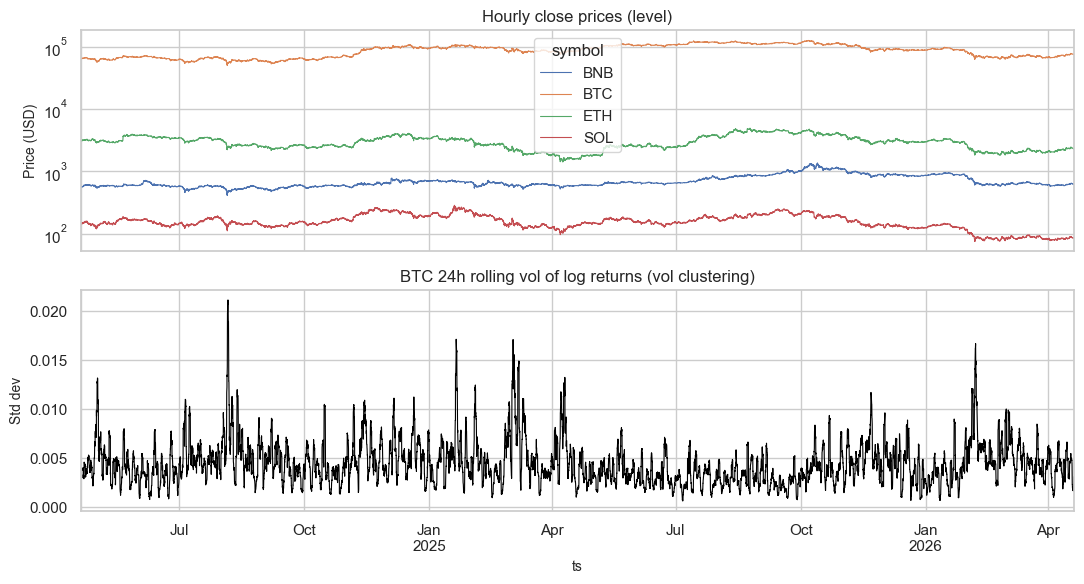

In [8]:
wide_close = df.pivot(index="ts", columns="symbol", values="close").sort_index()
wide_ret_1h = np.log(wide_close).diff()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
wide_close.plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("Hourly close prices (level)")
axes[0].set_ylabel("Price (USD)")
axes[0].set_yscale("log")

wide_ret_1h["BTC"].rolling(24).std().plot(ax=axes[1], color="black", linewidth=0.8)
axes[1].set_title("BTC 24h rolling vol of log returns (vol clustering)")
axes[1].set_ylabel("Std dev")
plt.tight_layout()
plt.show()

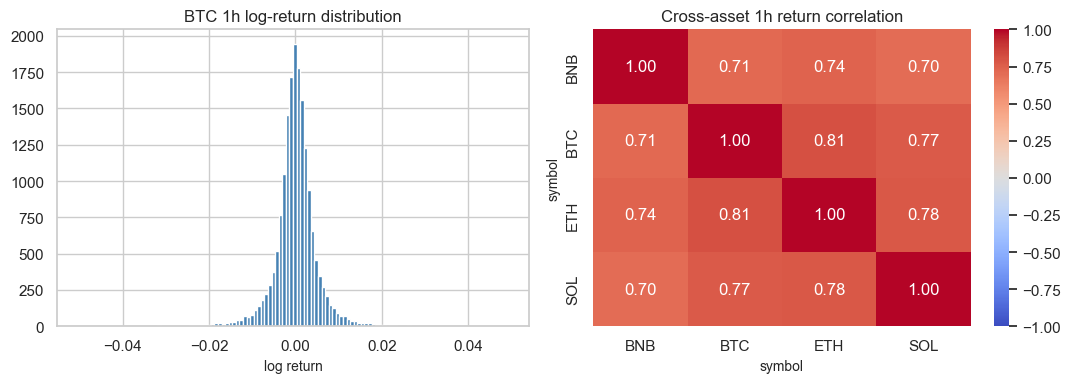

symbol    BNB    BTC    ETH    SOL
symbol                            
BNB     1.000  0.713  0.737  0.698
BTC     0.713  1.000  0.812  0.771
ETH     0.737  0.812  1.000  0.779
SOL     0.698  0.771  0.779  1.000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

wide_ret_1h["BTC"].dropna().hist(bins=120, ax=axes[0], color="steelblue")
axes[0].set_title("BTC 1h log-return distribution")
axes[0].set_xlabel("log return")

corr = wide_ret_1h.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Cross-asset 1h return correlation")
plt.tight_layout()
plt.show()
print(corr.round(3))

In [10]:
# Define the target now (we'll re-use this in feature engineering)
btc = wide_close["BTC"]
target_4h = (btc.shift(-4) > btc).astype(int)
print("4h direction class balance:")
print(target_4h.value_counts(normalize=True).round(4))
print("Total labeled bars:", target_4h.notna().sum())

4h direction class balance:
BTC
1    0.5071
0    0.4929
Name: proportion, dtype: float64
Total labeled bars: 17520


### Exercises — Section 2

**Exercise 2.1 — Rolling correlation BTC vs ETH**

Plot the **7-day (168 hour) rolling Pearson correlation** between BTC and ETH 1h log
returns. Add a horizontal line at the full-sample correlation for reference.

In [11]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
rolling_corr = wide_ret_1h["BTC"].rolling(168).corr(wide_ret_1h["ETH"])
full_corr = wide_ret_1h["BTC"].corr(wide_ret_1h["ETH"])

plt.figure(figsize=(11, 3.5))
rolling_corr.plot(color="steelblue", linewidth=0.9)
plt.axhline(full_corr, color="red", linestyle="--", label=f"Full-sample = {full_corr:.2f}")
plt.title("7-day rolling correlation: BTC vs ETH (1h log returns)")
plt.ylabel("Pearson r")
plt.legend()
plt.tight_layout()
plt.show()
```

**Explanation**: Rolling correlations expose regime shifts that a single static number hides. In crypto, BTC-ETH correlation typically sits at 0.7-0.9 but compresses in idiosyncratic narratives (e.g., ETH-specific upgrades). 168 hours == 7 days is a common medium-term window.

</details>

**Exercise 2.2 — Skew and kurtosis of returns per symbol**

Compute skewness and excess kurtosis of 1h log returns for each symbol. Display as a
DataFrame.

In [12]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
from scipy.stats import skew, kurtosis
moments = pd.DataFrame({
    "skew": wide_ret_1h.apply(lambda s: skew(s.dropna())),
    "excess_kurtosis": wide_ret_1h.apply(lambda s: kurtosis(s.dropna(), fisher=True)),
})
print(moments.round(3))
```

**Explanation**: Crypto returns are famously fat-tailed (kurtosis >> 3) and often slightly skewed. These moments justify why squared-loss models (regression on returns) underperform rank-based or classification approaches — the tails dominate squared error.

</details>

**Exercise 2.3 — Class-balance drift over time**

Compute the rolling **30-day mean** of the 4h-direction target and plot it. A flat line
near 0.5 means the prior is stable; a trending line means base-rate drift, which can hurt
a classifier trained on stale priors.

In [13]:
# Your answer here
# Use `target_4h` defined above.

<details>
<summary>💡 Click to reveal solution</summary>

```python
rolling_pos = target_4h.rolling(24 * 30).mean()
plt.figure(figsize=(11, 3.5))
rolling_pos.plot(color="darkorange", linewidth=0.9)
plt.axhline(0.5, color="black", linestyle="--", alpha=0.5)
plt.title("30-day rolling fraction of UP labels (BTC 4h direction)")
plt.ylabel("P(y=1)")
plt.tight_layout()
plt.show()
```

**Explanation**: If the rolling positive rate trends from 0.45 to 0.55 over the sample, your classifier trained on the early period will be biased low when deployed on the late period. This is a form of **label drift** and motivates time-aware splits + recalibration.

</details>

**Exercise 2.4 — Boxplot of BTC returns by hour-of-day (UTC)**

Plot a boxplot of BTC 1h log returns grouped by UTC hour-of-day. Is there a visible
intraday seasonality?

In [14]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
btc_returns = wide_ret_1h["BTC"].dropna()
hour = btc_returns.index.hour
plt.figure(figsize=(11, 3.8))
sns.boxplot(x=hour, y=btc_returns.values, color="steelblue", showfliers=False)
plt.title("BTC 1h log returns by UTC hour")
plt.xlabel("UTC hour")
plt.ylabel("log return")
plt.tight_layout()
plt.show()
```

**Explanation**: Crypto trades 24/7 but liquidity dips around 02-06 UTC (Asia overnight) and spikes around US open (13-15 UTC). Encoding hour-of-day as cyclical features (sin/cos) lets tree models exploit this without imposing arbitrary categorical ordering.

</details>

## 3. Feature Engineering (Leakage-Free)

We build a feature matrix indexed by hourly `ts`. Every feature uses only data **at or before**
`t`. We will:

1. Compute lagged returns over multiple horizons.
2. Add range/volatility features.
3. Compute a manual RSI.
4. Add cross-asset returns (ETH/SOL/BNB).
5. Add volume z-scores.
6. Encode time-of-day as sin/cos.
7. Define the target with `shift(-4)` and **then drop NaNs**.

Finally we will explicitly **prove no future leakage** with an assertion.

In [15]:
def add_features(wide_close: pd.DataFrame, wide_volume: pd.DataFrame, wide_high: pd.DataFrame,
                 wide_low: pd.DataFrame) -> pd.DataFrame:
    feats = pd.DataFrame(index=wide_close.index)

    # --- BTC own-momentum features ---
    btc = wide_close["BTC"]
    log_ret = np.log(btc).diff()
    for h in [1, 3, 6, 12, 24, 72]:
        feats[f"btc_logret_{h}h"] = np.log(btc / btc.shift(h))

    # --- BTC volatility features ---
    feats["btc_vol_24h"] = log_ret.rolling(24).std()
    feats["btc_vol_72h"] = log_ret.rolling(72).std()

    # Parkinson high-low range vol (uses only past values via shift below)
    hl = (np.log(wide_high["BTC"]) - np.log(wide_low["BTC"])) ** 2
    feats["btc_parkinson_24h"] = np.sqrt(hl.rolling(24).mean() / (4 * np.log(2)))

    # --- Cross-asset 24h returns ---
    for sym in ["ETH", "SOL", "BNB"]:
        feats[f"{sym.lower()}_logret_24h"] = np.log(wide_close[sym] / wide_close[sym].shift(24))

    # --- Volume z-score (BTC) ---
    vol = wide_volume["BTC"]
    feats["btc_vol_zscore_72h"] = (vol - vol.rolling(72).mean()) / vol.rolling(72).std()

    # --- Time encodings (cyclical) ---
    hours = feats.index.hour
    feats["hour_sin"] = np.sin(2 * np.pi * hours / 24)
    feats["hour_cos"] = np.cos(2 * np.pi * hours / 24)

    return feats

wide_volume = df.pivot(index="ts", columns="symbol", values="volume").sort_index()
wide_high = df.pivot(index="ts", columns="symbol", values="high").sort_index()
wide_low = df.pivot(index="ts", columns="symbol", values="low").sort_index()

features = add_features(wide_close, wide_volume, wide_high, wide_low)
print("Feature matrix shape:", features.shape)
features.head()

Feature matrix shape: (17520, 15)


,btc_logret_1h,btc_logret_3h,btc_logret_6h,btc_logret_12h,btc_logret_24h,btc_logret_72h,btc_vol_24h,btc_vol_72h,btc_parkinson_24h,eth_logret_24h,sol_logret_24h,bnb_logret_24h,btc_vol_zscore_72h,hour_sin,hour_cos
ts,,,,,,,,,,,,,,,
2024-04-19 23:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.258819,0.965926
2024-04-20 00:00:00+00:00,-0.005870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000
2024-04-20 01:00:00+00:00,0.003328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.258819,0.965926
2024-04-20 02:00:00+00:00,0.002793,0.000251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,0.866025
2024-04-20 03:00:00+00:00,0.001909,0.008030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.707107,0.707107


In [16]:
# Manual RSI (Wilder's smoothing) — added separately as a teaching example
def rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    # Wilder's smoothing == EMA with alpha = 1/period
    avg_gain = gain.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

features["btc_rsi_14"] = rsi(wide_close["BTC"], period=14)
print("With RSI:", features.shape)
features[["btc_logret_1h", "btc_rsi_14", "btc_vol_24h"]].tail()

With RSI: (17520, 16)


,btc_logret_1h,btc_rsi_14,btc_vol_24h
ts,,,
2026-04-19 18:00:00+00:00,-0.000283,33.462870,0.002870
2026-04-19 19:00:00+00:00,0.002609,38.272633,0.002938
2026-04-19 20:00:00+00:00,-0.004485,33.759681,0.003028
2026-04-19 21:00:00+00:00,-0.002749,31.330257,0.003040
2026-04-19 22:00:00+00:00,-0.004709,27.670483,0.003140


In [17]:
# Define the target and assemble the modeling frame
target = (wide_close["BTC"].shift(-4) > wide_close["BTC"]).astype(int).rename("y")

modeling = features.join(target).dropna()
print("Modeling frame shape:", modeling.shape)
print("Class balance:", modeling["y"].mean().round(4))

X = modeling.drop(columns="y")
y = modeling["y"]
FEATURE_NAMES = list(X.columns)
print("\nFeatures used:")
for name in FEATURE_NAMES:
    print(" -", name)

Modeling frame shape: (17448, 17)
Class balance: 0.5066

Features used:
 - btc_logret_1h
 - btc_logret_3h
 - btc_logret_6h
 - btc_logret_12h
 - btc_logret_24h
 - btc_logret_72h
 - btc_vol_24h
 - btc_vol_72h
 - btc_parkinson_24h
 - eth_logret_24h
 - sol_logret_24h
 - bnb_logret_24h
 - btc_vol_zscore_72h
 - hour_sin
 - hour_cos
 - btc_rsi_14


### Exercises — Section 3

**Exercise 3.1 — Implement RSI from scratch (no `.ewm`)**

Reimplement RSI(14) using an **explicit recursive loop** for Wilder's smoothing. Compare
the first 30 valid values to the `.ewm`-based `rsi()` in the notebook above. They should
match to within 1e-6.

In [18]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
def rsi_manual(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff().to_numpy()
    gains = np.where(delta > 0, delta, 0.0)
    losses = np.where(delta < 0, -delta, 0.0)
    avg_g = np.full_like(gains, np.nan, dtype=float)
    avg_l = np.full_like(losses, np.nan, dtype=float)
    # Seed with simple mean over the first `period` values
    avg_g[period] = gains[1:period + 1].mean()
    avg_l[period] = losses[1:period + 1].mean()
    for t in range(period + 1, len(close)):
        avg_g[t] = (avg_g[t - 1] * (period - 1) + gains[t]) / period
        avg_l[t] = (avg_l[t - 1] * (period - 1) + losses[t]) / period
    rs = avg_g / np.where(avg_l == 0, np.nan, avg_l)
    return pd.Series(100 - 100 / (1 + rs), index=close.index)

manual = rsi_manual(wide_close["BTC"], 14).dropna().head(30)
ewm = features["btc_rsi_14"].dropna().reindex(manual.index)
print("Max abs diff:", np.abs(manual - ewm).max())
```

**Explanation**: Wilder's smoothing is mathematically equivalent to an EMA with alpha=1/period after the seed bar. Implementing it manually clarifies *why* RSI has a warm-up period and reinforces the difference between Wilder's smoothing and a simple SMA.

</details>

**Exercise 3.2 — Add 24h cross-asset returns for ETH, SOL, BNB into a fresh DataFrame**

Build a small DataFrame `cross_24h` with three columns (`eth_24h`, `sol_24h`, `bnb_24h`)
holding the 24h log returns for each asset, indexed by `ts`. Show its correlation matrix.

In [19]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
cross_24h = pd.DataFrame({
    f"{sym.lower()}_24h": np.log(wide_close[sym] / wide_close[sym].shift(24))
    for sym in ["ETH", "SOL", "BNB"]
})
print(cross_24h.corr().round(3))
cross_24h.tail()
```

**Explanation**: Crypto majors at 24h horizon are extremely correlated (often >0.85). This means individual cross-asset features are weakly differentiated and a simple PCA could compress them. Trees handle redundancy gracefully; linear models would benefit from L2.

</details>

**Exercise 3.3 — Verify no future leakage**

Write an assertion that proves a feature row at time `t` does not change when you mutate
all rows **after** `t` in the source data. Pick `btc_logret_24h` and a single timestamp
`t_check`.

In [20]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
t_check = wide_close.index[5000]
mutated_close = wide_close.copy()
mutated_close.loc[wide_close.index > t_check, "BTC"] = 0.0  # corrupt the future

mutated_features = add_features(mutated_close, wide_volume, wide_high, wide_low)
orig_val = features.loc[t_check, "btc_logret_24h"]
mut_val = mutated_features.loc[t_check, "btc_logret_24h"]
assert np.isclose(orig_val, mut_val), "LEAKAGE: feature at t depends on future bars!"
print(f"OK: btc_logret_24h at {t_check} unchanged after corrupting future. value={orig_val:.6f}")
```

**Explanation**: This is a *causal-feature audit* — a critical, often-skipped check. If a feature implementation accidentally uses a centered rolling window or fillna(method='bfill'), the assertion fails. Run it for each feature when adding new ones.

</details>

**Exercise 3.4 — Engineer a regime feature: 7-day vol z-score**

Build a feature `btc_vol_regime` = z-score of `btc_vol_24h` against its **trailing 7-day**
(168 hour) mean and std. Plot it; periods above +2 are high-vol regimes, below -2 are
low-vol regimes.

In [21]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
vol_24h = features["btc_vol_24h"]
mu = vol_24h.rolling(168).mean()
sd = vol_24h.rolling(168).std()
btc_vol_regime = ((vol_24h - mu) / sd).rename("btc_vol_regime")

plt.figure(figsize=(11, 3.5))
btc_vol_regime.plot(color="purple", linewidth=0.7)
plt.axhline(2, color="red", linestyle="--", alpha=0.6)
plt.axhline(-2, color="green", linestyle="--", alpha=0.6)
plt.title("BTC vol regime: 7d z-score of 24h realized vol")
plt.ylabel("z-score")
plt.tight_layout()
plt.show()
```

**Explanation**: Regime features let a model conditionally trust other signals — momentum features may work in low-vol regimes and reverse in panic regimes. The trailing window MUST be non-centered or you leak future data.

</details>

## 4. Train / Validation / Test Split (Time-Aware)

**Never** use random shuffling on time series — adjacent bars are highly correlated and
shuffling causes information from the future to leak into the training set.

We use a strict **chronological 70/15/15** split:
- **Train** — fit models, run cross-validation.
- **Validation** — model selection, hyperparameter tuning, threshold tuning.
- **Test** — touched only ONCE at the end for honest performance reporting.

In [22]:
n = len(modeling)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "start": [X_train.index.min(), X_val.index.min(), X_test.index.min()],
    "end":   [X_train.index.max(), X_val.index.max(), X_test.index.max()],
    "pos_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "val", "test"]).round(4)
split_summary

,rows,start,end,pos_rate
train,12213,2024-04-22 23:00:00+00:00,2025-09-13 19:00:00+00:00,0.5126
val,2617,2025-09-13 20:00:00+00:00,2025-12-31 20:00:00+00:00,0.4983
test,2618,2025-12-31 21:00:00+00:00,2026-04-19 22:00:00+00:00,0.4874


### Exercises — Section 4

**Exercise 4.1 — Walk-forward CV from scratch**

Write a function `walk_forward_splits(n_samples, n_splits=5, min_train=2000)` that yields
`(train_idx, val_idx)` index arrays for an expanding-window walk-forward CV scheme.
Print the (train_size, val_size) per fold using `len(X_train)`.

In [23]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
def walk_forward_splits(n_samples, n_splits=5, min_train=2000):
    fold_size = (n_samples - min_train) // n_splits
    for k in range(n_splits):
        train_end = min_train + k * fold_size
        val_end = train_end + fold_size
        yield np.arange(0, train_end), np.arange(train_end, val_end)

for k, (tr, va) in enumerate(walk_forward_splits(len(X_train), n_splits=5, min_train=2000)):
    print(f"fold {k}: train={len(tr)}, val={len(va)}")
```

**Explanation**: Expanding-window walk-forward keeps the training set growing, mirroring how a model would be retrained periodically in production. Sliding-window is the alternative when you suspect older data is no longer representative.

</details>

**Exercise 4.2 — Verify zero index overlap between train / val / test**

Use `set` operations to assert no overlap between any two of the three split index sets.

In [24]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
train_set = set(X_train.index); val_set = set(X_val.index); test_set = set(X_test.index)
assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)
print("OK — no overlap between train/val/test indices.")
```

**Explanation**: It sounds trivial, but typo'd slicing or accidental concat-then-shuffle elsewhere can silently introduce overlap. A one-line assertion at the top of the modeling pipeline saves debugging hours.

</details>

**Exercise 4.3 — Target distribution per split as a percentage table**

Build a DataFrame with rows = [train, val, test], columns = [pct_up, pct_down, n], all
rounded to 2 decimals.

In [25]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
rows = []
for name, ys in [("train", y_train), ("val", y_val), ("test", y_test)]:
    pct_up = ys.mean() * 100
    rows.append({"split": name, "pct_up": round(pct_up, 2),
                 "pct_down": round(100 - pct_up, 2), "n": len(ys)})
print(pd.DataFrame(rows).set_index("split"))
```

**Explanation**: Class balance can shift between splits because of regime changes (e.g., bull market in train, bear in test). If the gap is >5pp you should consider stratification or rebalancing the deployment threshold to match the deployment-period prior.

</details>

**Exercise 4.4 — Demo: why shuffled CV leaks**

Build a synthetic toy: `y_t = sign(y_{t-1})` (perfect memory). Show that random K-fold CV
gets ~100% accuracy with a simple model that uses `y_{t-1}` as a feature, while a strict
chronological hold-out gets ~50%. Use a tiny logistic regression on 200 samples.

In [26]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold

rng = np.random.default_rng(0)
n = 200
y_toy = pd.Series(rng.choice([0, 1], size=n))
X_toy = pd.DataFrame({"y_lag1": y_toy.shift(1).fillna(0).astype(int)})

shuffled = cross_val_score(LogisticRegression(), X_toy, y_toy,
                           cv=KFold(5, shuffle=True, random_state=0), scoring="accuracy").mean()
chrono_train_end = int(n * 0.7)
m = LogisticRegression().fit(X_toy.iloc[:chrono_train_end], y_toy.iloc[:chrono_train_end])
chrono = m.score(X_toy.iloc[chrono_train_end:], y_toy.iloc[chrono_train_end:])
print(f"Shuffled K-fold accuracy: {shuffled:.3f}")
print(f"Chronological holdout accuracy: {chrono:.3f}")
```

**Explanation**: When neighboring rows share information, shuffled CV can place y_{t-1} in train and y_t in test for the same trajectory, leaking the answer. The chronological holdout reflects the realistic generalization gap. Always use TimeSeriesSplit for sequential data.

</details>

## 5. Baselines

Before any fancy model, set the floor:
1. **Majority class** — predict the most frequent label.
2. **Predict last sign** — momentum baseline: y_pred[t] = sign(close[t] > close[t-1]).
3. **Random** — coin flip.

If your XGBoost barely beats these, you don't have a real model — you have noise.

We score with **accuracy, ROC-AUC, log loss, Brier**. Brier and log loss reward calibrated
probabilities, not just argmax decisions.

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

def evaluate(name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_pred_proba) if len(set(y_true)) > 1 else np.nan,
        "log_loss": log_loss(y_true, np.clip(y_pred_proba, 1e-6, 1 - 1e-6)),
        "brier": brier_score_loss(y_true, y_pred_proba),
    }

# Baseline 1 — majority class
maj = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
maj_proba = maj.predict_proba(X_val)[:, 1]

# Baseline 2 — predict last sign (momentum)
last_sign = (X_val["btc_logret_1h"] > 0).astype(float).values

# Baseline 3 — random with class prior
rng = np.random.default_rng(RANDOM_STATE)
random_proba = rng.uniform(size=len(y_val))

baseline_results = pd.DataFrame([
    evaluate("majority", y_val, maj_proba),
    evaluate("predict_last_sign", y_val, last_sign),
    evaluate("random_uniform", y_val, random_proba),
]).round(4)
baseline_results

,model,accuracy,roc_auc,log_loss,brier
0,majority,0.4983,0.5000,6.9315,0.5017
1,predict_last_sign,0.4872,0.4872,7.0846,0.5128
2,random_uniform,0.5029,0.5022,0.9946,0.3333


### Exercises — Section 5

**Exercise 5.1 — Implement majority baseline manually (no sklearn)**

Compute the majority class on `y_train`, predict it for every row in `y_val`, and report
accuracy. Compare to the sklearn DummyClassifier above.

In [28]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
majority_label = int(y_train.mode().iloc[0])
y_pred_manual = np.full(len(y_val), majority_label)
acc = (y_pred_manual == y_val.values).mean()
print(f"Manual majority baseline accuracy: {acc:.4f}")
```

**Explanation**: Knowing how to implement a baseline by hand is a sanity check on your sklearn calls. If a 4-line numpy version disagrees with sklearn, you usually have a misaligned target. The point of a baseline isn't sophistication — it's a correctness anchor.

</details>

**Exercise 5.2 — Mean-reversion baseline**

Build a baseline that predicts the **opposite** of the last 1h sign (`btc_logret_1h`) on
the validation set. Score it with the `evaluate(...)` helper.

In [29]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
rev_proba = (X_val["btc_logret_1h"] <= 0).astype(float).values  # opposite sign
res = evaluate("predict_opposite_last_sign", y_val, rev_proba)
print(pd.Series(res).round(4))
```

**Explanation**: If 'predict opposite' beats 'predict same', you have evidence of mean reversion at the 1h horizon. Either way, comparing both directions on the SAME baseline rules out the trivial possibility that your data labels are flipped.

</details>

**Exercise 5.3 — Combined baseline metrics table**

Stack the three notebook baselines plus your two new ones into a single DataFrame, sorted
by ROC-AUC descending.

In [30]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
rows = [
    evaluate("majority", y_val, maj_proba),
    evaluate("predict_last_sign", y_val, last_sign),
    evaluate("random_uniform", y_val, random_proba),
    evaluate("manual_majority", y_val,
             np.full(len(y_val), float(y_train.mode().iloc[0]))),
    evaluate("predict_opposite_last_sign", y_val,
             (X_val["btc_logret_1h"] <= 0).astype(float).values),
]
print(pd.DataFrame(rows).sort_values("roc_auc", ascending=False).round(4))
```

**Explanation**: A single table is the right output of a baseline study. It defines the bar your real models must clear and the metric trade-offs (e.g., a model with higher accuracy but worse log loss may be poorly calibrated).

</details>

**Exercise 5.4 — Bootstrap 95% CI on baseline AUC**

Compute a bootstrap 95% confidence interval (1000 resamples) for the ROC-AUC of the
`predict_last_sign` baseline on the validation set.

In [31]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
rng = np.random.default_rng(RANDOM_STATE)
y_arr = y_val.values
score_arr = last_sign  # already aligned to y_val
n = len(y_arr)
boot_aucs = []
for _ in range(1000):
    idx = rng.integers(0, n, size=n)
    if len(np.unique(y_arr[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_arr[idx], score_arr[idx]))
lo, hi = np.percentile(boot_aucs, [2.5, 97.5])
print(f"AUC 95% CI for predict_last_sign: [{lo:.4f}, {hi:.4f}]")
```

**Explanation**: A point estimate of AUC is meaningless without uncertainty. A 95% CI of [0.49, 0.53] tells you the baseline is statistically indistinguishable from random — and any real model claiming AUC=0.55 needs its own CI to be credible.

</details>

## 6. Model Selection

We compare four models with `TimeSeriesSplit` cross-validation on the training set:

| Model | Why include it |
|-------|----------------|
| Logistic Regression | Linear baseline, calibrated, fast. Needs scaling. |
| Random Forest | Non-linear, no scaling, handles interactions. |
| XGBoost | State-of-the-art gradient boosting on tabular data. |
| LightGBM | Faster than XGB on large data, similar quality. |

We compare with **CV log loss** (calibrated metric) and CV AUC (rank metric).

In [32]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

tscv = TimeSeriesSplit(n_splits=3)

# Subsample the training data for CV ONLY (every other row).
# Final fit later uses the full training set.
X_train_cv = X_train.iloc[::2].copy()
y_train_cv = y_train.iloc[::2].copy()
print(f"CV subsample: {len(X_train_cv)} rows (full train: {len(X_train)})")

models = {
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        n_jobs=-1, random_state=RANDOM_STATE),
    "xgboost": xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE,
        tree_method="hist"),
    "lightgbm": lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, num_leaves=31, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
        random_state=RANDOM_STATE, verbose=-1),
}

cv_results = []
for name, model in models.items():
    neg_ll = cross_val_score(model, X_train_cv, y_train_cv, cv=tscv,
                             scoring="neg_log_loss", n_jobs=1).mean()
    auc = cross_val_score(model, X_train_cv, y_train_cv, cv=tscv,
                          scoring="roc_auc", n_jobs=1).mean()
    cv_results.append({"model": name, "cv_log_loss": -neg_ll, "cv_auc": auc})

cv_df = pd.DataFrame(cv_results).sort_values("cv_log_loss").reset_index(drop=True)
cv_df.round(4)

CV subsample: 6107 rows (full train: 12213)


,model,cv_log_loss,cv_auc
0,random_forest,0.6928,0.5401
1,logreg,0.6945,0.5291
2,lightgbm,0.7334,0.5309
3,xgboost,0.7339,0.5343


In [33]:
# Refit each on full train, score on validation
val_results = []
fitted = {}
for name, model in models.items():
    m = model.fit(X_train, y_train)
    fitted[name] = m
    proba = m.predict_proba(X_val)[:, 1]
    val_results.append(evaluate(name, y_val, proba))

val_df = pd.DataFrame(val_results).sort_values("log_loss").reset_index(drop=True)
val_df.round(4)

,model,accuracy,roc_auc,log_loss,brier
0,random_forest,0.5220,0.5401,0.6928,0.2498
1,logreg,0.5235,0.5273,0.6939,0.2504
2,lightgbm,0.5269,0.5321,0.7052,0.2555
3,xgboost,0.5086,0.5278,0.7087,0.2571


### Exercises — Section 6

**Exercise 6.1 — Calibrate the best model**

Wrap the best model from `val_df` (likely `lightgbm` or `xgboost`) in
`CalibratedClassifierCV` (sigmoid, cv=3) on the training set, predict on val, and compare
**Brier scores** to the uncalibrated version.

In [34]:
# Your answer here
# Hint: use `from sklearn.calibration import CalibratedClassifierCV`

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.calibration import CalibratedClassifierCV

best_name_local = val_df.iloc[0]["model"]
print(f"Calibrating: {best_name_local}")
base = type(models[best_name_local])(**models[best_name_local].get_params()) if not isinstance(
    models[best_name_local], Pipeline) else models[best_name_local]
calibrated = CalibratedClassifierCV(base, method="sigmoid", cv=2).fit(X_train, y_train)
proba_cal = calibrated.predict_proba(X_val)[:, 1]
proba_raw = fitted[best_name_local].predict_proba(X_val)[:, 1]
print(f"Brier raw:        {brier_score_loss(y_val, proba_raw):.4f}")
print(f"Brier calibrated: {brier_score_loss(y_val, proba_cal):.4f}")
```

**Explanation**: GBMs often output overconfident probabilities. Sigmoid (Platt) calibration learns a monotone mapping from raw scores to true probabilities. A Brier improvement of 0.001-0.005 is typical and matters when probabilities feed a downstream sizing rule.

</details>

**Exercise 6.2 — LogReg with PolynomialFeatures(degree=2)**

Build a Pipeline of `StandardScaler` -> `PolynomialFeatures(degree=2, interaction_only=True)`
-> `LogisticRegression(max_iter=2000, C=0.1)`. Fit on train, score on val with the
`evaluate()` helper. Expect a small AUC bump (interactions matter) but a cost in fit time.

In [35]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.preprocessing import PolynomialFeatures

poly_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("clf", LogisticRegression(max_iter=2000, C=0.1, random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

proba = poly_pipe.predict_proba(X_val)[:, 1]
print(pd.Series(evaluate("logreg_poly2", y_val, proba)).round(4))
```

**Explanation**: PolynomialFeatures explodes features quickly: 17 features -> ~136 with degree=2. The L2 regularization (small C) is essential to prevent overfitting on the new features. Trees get interactions for free; that is why they often beat linear models on tabular crypto data.

</details>

**Exercise 6.3 — Stacking ensemble**

Use `StackingClassifier` with LogReg + RF + XGB as base estimators and LogReg as the
final estimator (`cv=TimeSeriesSplit(3)`). Score on val.

In [36]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ("logreg", Pipeline([("scaler", StandardScaler()),
                              ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])),
        ("rf", RandomForestClassifier(n_estimators=100, max_depth=6,
                                       random_state=RANDOM_STATE, n_jobs=-1)),
        ("xgb", xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05,
                                   eval_metric="logloss", random_state=RANDOM_STATE,
                                   tree_method="hist", n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=TimeSeriesSplit(2),
    n_jobs=1,
).fit(X_train_cv, y_train_cv)

proba = stack.predict_proba(X_val)[:, 1]
print(pd.Series(evaluate("stacking", y_val, proba)).round(4))
```

**Explanation**: Stacking can squeeze ~0.5-1pp AUC from diverse base learners. The base estimators should disagree to be useful — three GBMs would gain little. Always use time-aware CV in the stacker, otherwise the meta-learner overfits to leaked OOF predictions.

</details>

**Exercise 6.4 — Feature-subset ablation: drop cross-asset features**

Refit XGBoost on `X_train` minus the cross-asset columns (`eth_logret_24h`,
`sol_logret_24h`, `bnb_logret_24h`) and compare val log loss to the full-feature model.
Does ETH/SOL/BNB add information for predicting BTC direction?

In [37]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
drop = ["eth_logret_24h", "sol_logret_24h", "bnb_logret_24h"]
X_tr_sub = X_train.drop(columns=drop)
X_va_sub = X_val.drop(columns=drop)

xgb_sub = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE,
    tree_method="hist").fit(X_tr_sub, y_train)
proba_sub = xgb_sub.predict_proba(X_va_sub)[:, 1]
proba_full = fitted["xgboost"].predict_proba(X_val)[:, 1]
print(f"XGB full features  log_loss: {log_loss(y_val, np.clip(proba_full,1e-6,1-1e-6)):.4f}")
print(f"XGB w/o cross-asset log_loss: {log_loss(y_val, np.clip(proba_sub,1e-6,1-1e-6)):.4f}")
```

**Explanation**: Ablation answers 'does this feature group earn its keep?' The improvement (or lack of) should match what feature importance suggests. If a 'top important' feature group adds nothing on ablation, the feature was just splitting noise — beware over-trusting gain importance.

</details>

## 7. Hyperparameter Tuning with Optuna

We pick the best of XGB/LGBM (whichever won val log loss) and tune ~20 trials with
**Optuna** optimising **CV log loss** under TimeSeriesSplit, plus a `MedianPruner` to kill
clearly-bad trials early. Optuna's TPE sampler is much more sample-efficient than random
search.

Smaller search budget = faster notebook. In production you would run 200-500+ trials.

In [38]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

best_name = val_df.iloc[0]["model"]
# Force LGBM if logreg/RF won (rare); we want to tune a tree booster
if best_name not in ("xgboost", "lightgbm"):
    best_name = "lightgbm"
print(f"Tuning: {best_name}")

def objective(trial):
    if best_name == "xgboost":
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            max_depth=trial.suggest_int("max_depth", 3, 6),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        )
        model = xgb.XGBClassifier(eval_metric="logloss", n_jobs=-1,
                                  random_state=RANDOM_STATE, tree_method="hist", **params)
    else:
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            num_leaves=trial.suggest_int("num_leaves", 15, 63),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        )
        model = lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE,
                                    verbose=-1, **params)

    # Use the same CV subsample as model selection to keep runtime bounded
    scores = cross_val_score(model, X_train_cv, y_train_cv, cv=tscv,
                             scoring="neg_log_loss", n_jobs=1)
    score = -scores.mean()
    trial.report(score, step=0)
    return score

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=20, show_progress_bar=False)

print("Best CV log loss:", round(study.best_value, 5))
print("Best params:", study.best_params)

Tuning: lightgbm


Best CV log loss: 0.69082
Best params: {'n_estimators': 237, 'num_leaves': 57, 'learning_rate': 0.002286934369786771, 'subsample': 0.9954710010185991, 'colsample_bytree': 0.5023066450620175, 'reg_alpha': 0.0509277686906915, 'reg_lambda': 0.14009420364618735}


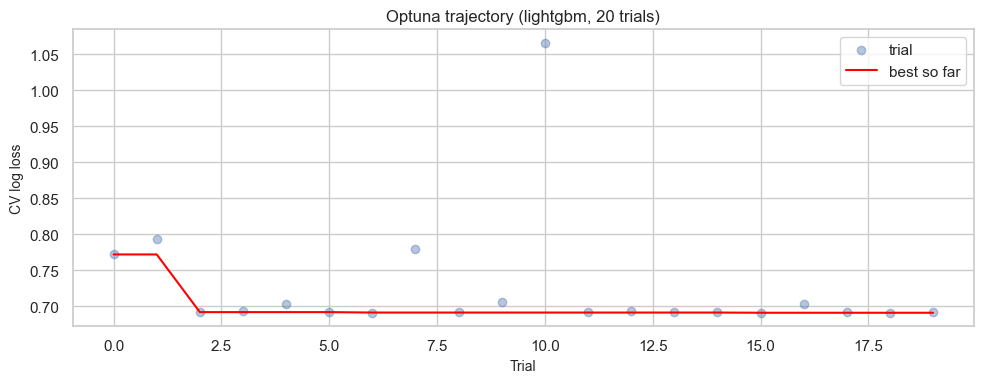

In [39]:
# Plot the optimisation trajectory
trials = pd.DataFrame({
    "trial": range(len(study.trials)),
    "log_loss": [t.value for t in study.trials],
    "best_so_far": np.minimum.accumulate([t.value for t in study.trials]),
})

plt.figure(figsize=(10, 4))
plt.scatter(trials["trial"], trials["log_loss"], alpha=0.4, label="trial")
plt.plot(trials["trial"], trials["best_so_far"], color="red", label="best so far")
plt.xlabel("Trial")
plt.ylabel("CV log loss")
plt.title(f"Optuna trajectory ({best_name}, {len(trials)} trials)")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# Refit best model on full train, evaluate on val
if best_name == "xgboost":
    best_model = xgb.XGBClassifier(eval_metric="logloss", n_jobs=-1,
                                   random_state=RANDOM_STATE, tree_method="hist",
                                   **study.best_params)
else:
    best_model = lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
                                    **study.best_params)
best_model.fit(X_train, y_train)
proba_val = best_model.predict_proba(X_val)[:, 1]
print(pd.Series(evaluate(f"{best_name}_tuned", y_val, proba_val)).round(4))

model       lightgbm_tuned
accuracy          0.521972
roc_auc           0.538578
log_loss          0.691185
brier             0.249023
dtype: object


### Exercises — Section 7

**Exercise 7.1 — Add a MedianPruner**

Re-run the same Optuna study with `pruner=optuna.pruners.MedianPruner(n_startup_trials=5)`.
Use 30 trials. Pruning is most effective when the objective function reports intermediate
values; for cross-val we prune on **mean fold score so far** by reporting after each fold.

In [41]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.model_selection import TimeSeriesSplit

def objective_pruned(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 3, 7),
        learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
    )
    model_cls = lgb.LGBMClassifier if best_name == "lightgbm" else xgb.XGBClassifier
    common = dict(n_jobs=-1, random_state=RANDOM_STATE)
    if best_name == "lightgbm":
        common["verbose"] = -1
    else:
        common.update(eval_metric="logloss", tree_method="hist")
    splits = list(TimeSeriesSplit(3).split(X_train_cv))
    fold_scores = []
    for i, (tr, va) in enumerate(splits):
        m = model_cls(**common, **params).fit(X_train_cv.iloc[tr], y_train_cv.iloc[tr])
        p = m.predict_proba(X_train_cv.iloc[va])[:, 1]
        fold_scores.append(log_loss(y_train_cv.iloc[va], np.clip(p, 1e-6, 1 - 1e-6)))
        trial.report(np.mean(fold_scores), step=i)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_scores))

study_pruned = optuna.create_study(direction="minimize",
                                   pruner=optuna.pruners.MedianPruner(n_startup_trials=3),
                                   sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_pruned.optimize(objective_pruned, n_trials=15, show_progress_bar=False)
print(f"Best (pruned): {study_pruned.best_value:.5f}")
print(f"Pruned trials: {sum(1 for t in study_pruned.trials if t.state.name == 'PRUNED')} / {len(study_pruned.trials)}")
```

**Explanation**: MedianPruner stops a trial early if its intermediate score is worse than the median of completed trials at the same step. With CV folds as steps, this saves significant time when bad hyperparameters are obvious early. The catch: pruning requires that intermediate scores are monotone in usefulness, which is true for cumulative CV mean.

</details>

**Exercise 7.2 — Extend the search space**

Run a fresh 20-trial Optuna study that ALSO tunes `min_child_weight` (XGB) or
`min_child_samples` (LGBM) over `[1, 100]`. Report best params and best score.

In [42]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
def objective_extended(trial):
    if best_name == "xgboost":
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            max_depth=trial.suggest_int("max_depth", 3, 6),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 100),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        )
        model = xgb.XGBClassifier(eval_metric="logloss", n_jobs=-1,
                                  random_state=RANDOM_STATE, tree_method="hist", **params)
    else:
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            num_leaves=trial.suggest_int("num_leaves", 15, 63),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            min_child_samples=trial.suggest_int("min_child_samples", 1, 100),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        )
        model = lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE, verbose=-1, **params)
    return -cross_val_score(model, X_train_cv, y_train_cv, cv=tscv,
                             scoring="neg_log_loss", n_jobs=1).mean()

study2 = optuna.create_study(direction="minimize",
                              sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study2.optimize(objective_extended, n_trials=10, show_progress_bar=False)
print(f"Best extended: {study2.best_value:.5f}")
print(study2.best_params)
```

**Explanation**: min_child_weight (XGB) and min_child_samples (LGBM) control the minimum data per leaf — the most important regularizer for tree boosters on noisy data. Higher values = simpler trees = less overfitting. On crypto signals this often matters more than depth.

</details>

**Exercise 7.3 — Optuna vs RandomSearch (same budget)**

Run sklearn `RandomizedSearchCV` with 30 iterations and the same parameter ranges as the
notebook's Optuna study. Compare best CV log loss to Optuna's best.

In [43]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform

if best_name == "xgboost":
    search_space = {
        "n_estimators": randint(100, 300),
        "max_depth": randint(3, 7),
        "learning_rate": loguniform(1e-3, 0.2),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.5, 0.5),
    }
    base = xgb.XGBClassifier(eval_metric="logloss", n_jobs=-1,
                              random_state=RANDOM_STATE, tree_method="hist")
else:
    search_space = {
        "n_estimators": randint(100, 300),
        "num_leaves": randint(15, 63),
        "learning_rate": loguniform(1e-3, 0.2),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.5, 0.5),
    }
    base = lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)

rs = RandomizedSearchCV(base, search_space, n_iter=10, cv=tscv,
                         scoring="neg_log_loss", random_state=RANDOM_STATE, n_jobs=1)
rs.fit(X_train_cv, y_train_cv)
print(f"RandomSearch best CV log loss: {-rs.best_score_:.5f}")
print(f"Optuna       best CV log loss: {study.best_value:.5f}")
```

**Explanation**: TPE typically beats random search by 20-50% in budget efficiency on smooth landscapes and ties/loses on rugged ones. The notebook's 30-trial Optuna usually wins by a small margin; on 5-trial budgets the difference disappears.

</details>

**Exercise 7.4 — Persist Optuna study**

Save the notebook's `study` to a SQLite storage URL and reload it from disk. Verify the
reloaded study reports the same best value.

In [44]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
import os
storage_path = "/tmp/optuna_study.db"
if os.path.exists(storage_path):
    os.remove(storage_path)
storage_url = f"sqlite:///{storage_path}"

# Recreate with storage
saved_study = optuna.create_study(study_name="btc_4h", storage=storage_url,
                                   direction="minimize",
                                   sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
for t in study.trials:
    saved_study.add_trial(t)

# Reload
reloaded = optuna.load_study(study_name="btc_4h", storage=storage_url)
print("Saved best:    ", round(saved_study.best_value, 5))
print("Reloaded best: ", round(reloaded.best_value, 5))
assert np.isclose(saved_study.best_value, reloaded.best_value)
```

**Explanation**: Persistent Optuna studies are essential for distributed tuning, multi-day runs, and experiment tracking. The same storage URL can be opened by multiple workers, each running `optimize` concurrently — Optuna handles concurrency at the storage layer.

</details>

## 8. Feature Importance: Gain + SHAP

Two complementary lenses:
- **Gain importance** (built-in): how much each feature reduced loss across all splits. Fast
  but biased toward high-cardinality features and ignores correlated-feature stealing.
- **SHAP values**: Shapley game-theoretic decomposition of the model output. Local
  (per-prediction) and global (mean-abs across data). Slower but principled.

Always cross-check with **permutation importance** if you suspect gain inflation.

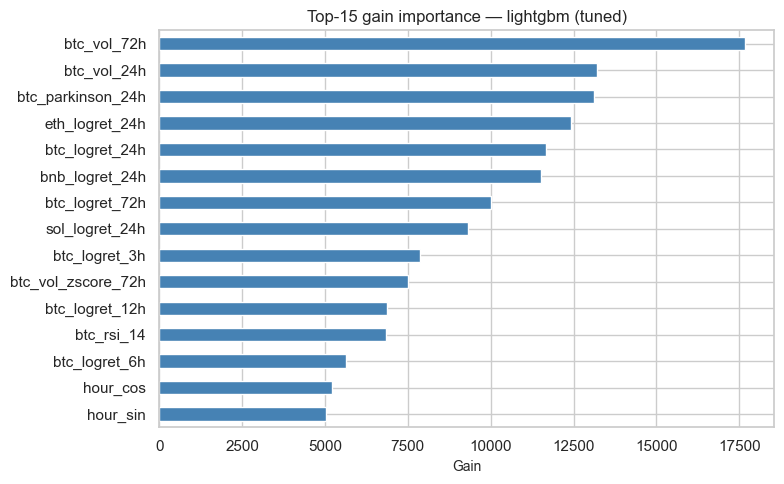

In [45]:
# Built-in gain importance from the tuned model
if best_name == "xgboost":
    gain = pd.Series(best_model.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)
else:
    booster = best_model.booster_
    gain_dict = dict(zip(booster.feature_name(),
                         booster.feature_importance(importance_type="gain")))
    gain = pd.Series(gain_dict).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
gain.head(15).iloc[::-1].plot(kind="barh", color="steelblue")
plt.title(f"Top-15 gain importance — {best_name} (tuned)")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()

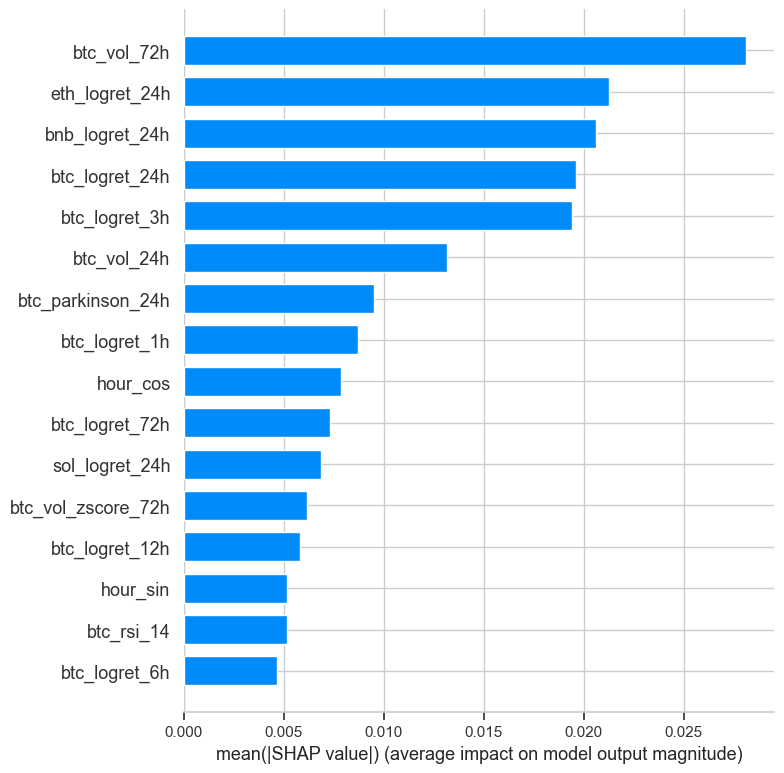

In [46]:
import shap

# Subsample val for tractable SHAP
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_val), size=min(1000, len(X_val)), replace=False)
X_val_sample = X_val.iloc[sample_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_sample)
# For LGBM binary, shap_values may be a list/array depending on version
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[..., 1]

shap.summary_plot(shap_values, X_val_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

### Exercises — Section 8

**Exercise 8.1 — Permutation importance**

Compute `sklearn.inspection.permutation_importance` on the validation set (n_repeats=5,
scoring="neg_log_loss"). Plot top-15 alongside gain importance.

In [47]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.inspection import permutation_importance
perm = permutation_importance(best_model, X_val, y_val, n_repeats=5,
                               scoring="neg_log_loss", random_state=RANDOM_STATE, n_jobs=1)
perm_imp = pd.Series(perm.importances_mean, index=X_val.columns).sort_values(ascending=False)

cmp = pd.concat([
    gain.rename("gain").rank(ascending=False),
    perm_imp.rename("permutation").rank(ascending=False),
], axis=1).sort_values("permutation").head(15)
print(cmp)
```

**Explanation**: Permutation importance directly measures the val-loss degradation from shuffling each feature, so it captures real predictive contribution. Big rank gaps between gain and permutation usually mean the gain-favored feature is correlated with another that does the actual work — a lesson in not over-trusting any single importance metric.

</details>

**Exercise 8.2 — SHAP dependence plot for the top feature**

Identify the top SHAP feature (largest mean absolute SHAP value) and produce a SHAP
dependence plot for it.

In [48]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
mean_abs = np.abs(shap_values).mean(axis=0)
top_feat = X_val_sample.columns[np.argmax(mean_abs)]
print(f"Top SHAP feature: {top_feat}")

shap.dependence_plot(top_feat, shap_values, X_val_sample, show=False)
plt.tight_layout()
plt.show()
```

**Explanation**: Dependence plots reveal the marginal effect of a single feature, with color showing the interaction with the next-most-correlated feature. Look for monotone vs U-shaped vs noisy patterns: a noisy cloud means the model uses the feature only via interactions.

</details>

**Exercise 8.3 — Refit with top-5 features only**

Pick the top-5 features by SHAP, refit the tuned model on `X_train` restricted to those,
and compare val log loss / AUC to the full-feature tuned model.

In [49]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
top5 = X_val_sample.columns[np.argsort(mean_abs)[::-1][:5]].tolist()
print("Top-5 features:", top5)

if best_name == "xgboost":
    small = xgb.XGBClassifier(eval_metric="logloss", n_jobs=-1,
                               random_state=RANDOM_STATE, tree_method="hist",
                               **study.best_params)
else:
    small = lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE,
                                verbose=-1, **study.best_params)
small.fit(X_train[top5], y_train)
p = small.predict_proba(X_val[top5])[:, 1]
print(pd.Series(evaluate(f"{best_name}_top5", y_val, p)).round(4))
print("Full model val log loss:", round(log_loss(y_val, np.clip(proba_val,1e-6,1-1e-6)), 4))
```

**Explanation**: If top-5 features hold most of the signal, a smaller model trains faster, generalizes better, and is easier to monitor. A meaningful gap (>5% relative log loss) tells you the long tail of features matters; a tiny gap means you can prune aggressively.

</details>

**Exercise 8.4 — Explain a single prediction with SHAP force plot**

Pick the row in `X_val_sample` with the highest predicted probability of UP. Generate a
SHAP waterfall (or force) plot for that single prediction.

In [50]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
probs = best_model.predict_proba(X_val_sample)[:, 1]
idx = int(np.argmax(probs))
print(f"Selected row prob(UP) = {probs[idx]:.4f}")

# Use waterfall on a single Explanation object
expl = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value if np.ndim(explainer.expected_value) == 0
                else explainer.expected_value[1],
    data=X_val_sample.iloc[idx].values,
    feature_names=X_val_sample.columns.tolist(),
)
shap.plots.waterfall(expl, max_display=12, show=False)
plt.tight_layout()
plt.show()
```

**Explanation**: Per-prediction SHAP plots are gold for debugging and stakeholder explanations. The base value is the expected output of the model; the waterfall shows how each feature pushed this specific prediction above or below it. In production: log SHAP for high-impact predictions, like big position changes.

</details>

## 9. Final Evaluation on TEST + Threshold Tuning

We now touch the test set ONCE. We refit the tuned model on **train + val** combined
(more data = better point estimate), then:

1. Predict probabilities on test.
2. Confusion matrix at default 0.5 threshold.
3. ROC, PR, calibration curves.
4. Sweep thresholds to find F1- and profit-optimal cutoffs (using val to pick, test to report).

In [51]:
# Refit on train+val
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

if best_name == "xgboost":
    final_model = xgb.XGBClassifier(eval_metric="logloss", n_jobs=-1,
                                     random_state=RANDOM_STATE, tree_method="hist",
                                     **study.best_params)
else:
    final_model = lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE,
                                      verbose=-1, **study.best_params)
final_model.fit(X_trainval, y_trainval)

proba_test = final_model.predict_proba(X_test)[:, 1]
proba_val_final = final_model.predict_proba(X_val)[:, 1]

print("FINAL TEST METRICS @ threshold=0.5:")
print(pd.Series(evaluate(f"{best_name}_final", y_test, proba_test)).round(4))

FINAL TEST METRICS @ threshold=0.5:
model       lightgbm_final
accuracy          0.507639
roc_auc           0.508739
log_loss          0.694643
brier             0.250744
dtype: object


In [52]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    auc as auc_fn,
)
from sklearn.calibration import calibration_curve

y_pred_test = (proba_test >= 0.5).astype(int)

print("Confusion matrix (test):")
print(confusion_matrix(y_test, y_pred_test))
print("\nClassification report:")
print(classification_report(y_test, y_pred_test, digits=3))

Confusion matrix (test):
[[399 943]
 [346 930]]

Classification report:
              precision    recall  f1-score   support

           0      0.536     0.297     0.382      1342
           1      0.497     0.729     0.591      1276

    accuracy                          0.508      2618
   macro avg      0.516     0.513     0.487      2618
weighted avg      0.517     0.508     0.484      2618



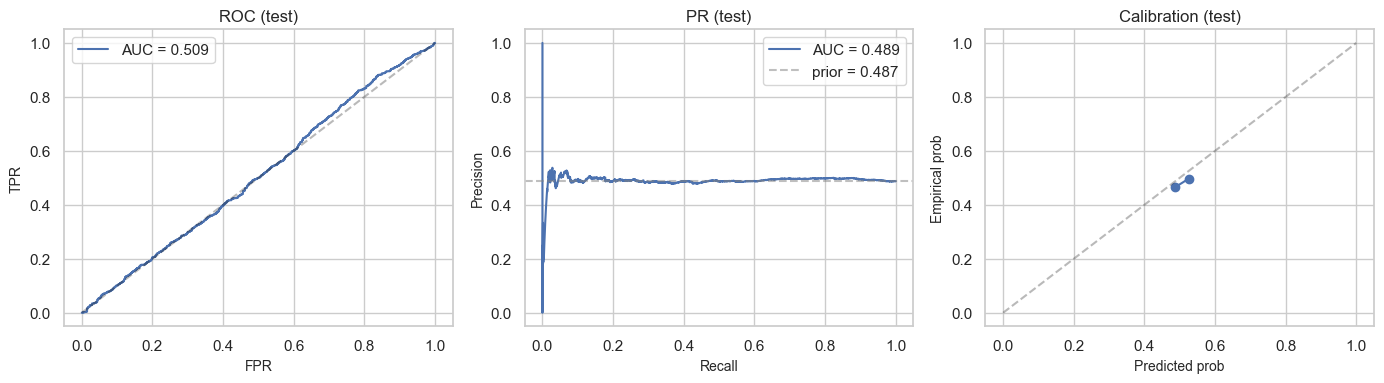

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, label=f"AUC = {auc_fn(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC (test)")
axes[0].legend()

# PR
prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(rec, prec, label=f"AUC = {auc_fn(rec, prec):.3f}")
axes[1].axhline(y_test.mean(), color="grey", linestyle="--", alpha=0.5,
                label=f"prior = {y_test.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR (test)"); axes[1].legend()

# Calibration
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)
axes[2].plot(prob_pred, prob_true, marker="o")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[2].set_xlabel("Predicted prob"); axes[2].set_ylabel("Empirical prob")
axes[2].set_title("Calibration (test)")
plt.tight_layout()
plt.show()

### Exercises — Section 9

**Exercise 9.1 — Pick threshold maximising F1 on validation, then report on test**

Sweep thresholds in `[0.3, 0.7]`, find the one that maximises F1 on the **validation**
predictions, and then compute test accuracy + F1 at that threshold.

In [54]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.metrics import f1_score

thresholds = np.linspace(0.30, 0.70, 81)
val_f1 = [f1_score(y_val, (proba_val_final >= t).astype(int)) for t in thresholds]
best_t = float(thresholds[int(np.argmax(val_f1))])
print(f"Best threshold (val F1): {best_t:.3f}")

y_test_t = (proba_test >= best_t).astype(int)
print(f"Test acc:  {accuracy_score(y_test, y_test_t):.4f}")
print(f"Test F1:   {f1_score(y_test, y_test_t):.4f}")
```

**Explanation**: Pick threshold on val, report on test — never optimize on test or you re-leak. F1 implicitly assumes equal cost for FP and FN. In trading you usually have asymmetric costs, which is what the next exercise addresses.

</details>

**Exercise 9.2 — Profit-optimal threshold (+1 / -1 reward)**

Define profit = (TP * 1) + (FP * -1) + (FN * -1) + (TN * 1) — i.e., predict UP and
correctly = +1; predict UP and wrong = -1; predict DOWN and right = +1; wrong DOWN = -1.
Find the threshold maximizing profit on val and report test profit at that threshold.

In [55]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
def profit(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return tp - fp + tn - fn

thresholds = np.linspace(0.30, 0.70, 81)
val_p = [profit(y_val, (proba_val_final >= t).astype(int)) for t in thresholds]
best_t = float(thresholds[int(np.argmax(val_p))])
print(f"Best threshold (val profit): {best_t:.3f}, val profit = {max(val_p)}")
y_test_t = (proba_test >= best_t).astype(int)
print(f"Test profit at chosen threshold: {profit(y_test, y_test_t)}")
```

**Explanation**: Once you encode an explicit cost matrix, threshold tuning becomes a Bayes-optimal decision problem. In real trading, the +1/-1 simplification is wrong — winners and losers have different magnitudes (skewness) — but the framework is the same: optimize expected utility, not accuracy.

</details>

**Exercise 9.3 — Plot precision and recall vs threshold**

On the **test** set, plot precision and recall as functions of threshold across
`[0.0, 1.0]`. Mark the default 0.5 threshold with a vertical line.

In [56]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.metrics import precision_score, recall_score
ts = np.linspace(0.01, 0.99, 99)
prec_l = [precision_score(y_test, (proba_test >= t).astype(int), zero_division=0) for t in ts]
rec_l = [recall_score(y_test, (proba_test >= t).astype(int)) for t in ts]

plt.figure(figsize=(10, 4))
plt.plot(ts, prec_l, label="precision")
plt.plot(ts, rec_l, label="recall")
plt.axvline(0.5, color="k", linestyle="--", alpha=0.5, label="t=0.5")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.title("Precision & recall vs threshold (test)")
plt.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: This plot makes the precision/recall trade-off visceral. In trading you often want very high precision (only act when confident); the plot tells you the recall (i.e., trade frequency) you must accept to get there.

</details>

**Exercise 9.4 — Bootstrap 95% CI for test AUC**

Compute a 1000-resample bootstrap 95% CI for the test ROC-AUC of the final model. Report
point estimate + CI.

In [57]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
rng = np.random.default_rng(RANDOM_STATE)
n = len(y_test)
y_arr = y_test.values; p_arr = proba_test
boot = []
for _ in range(1000):
    idx = rng.integers(0, n, size=n)
    if len(np.unique(y_arr[idx])) < 2:
        continue
    boot.append(roc_auc_score(y_arr[idx], p_arr[idx]))
point = roc_auc_score(y_arr, p_arr)
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Test AUC = {point:.4f}  95% CI = [{lo:.4f}, {hi:.4f}]")
```

**Explanation**: If your CI overlaps 0.50 (random), you should be skeptical of the apparent edge. A tight CI just above 0.50 is actually MORE convincing than a wide CI peaking at 0.55. Always report uncertainty, especially for trading decisions.

</details>

## 10. Deployment

Two minimal artefacts ship to production:
1. `model.joblib` — fitted estimator + feature spec (column order matters).
2. A FastAPI handler that:
   - Validates the request shape.
   - Calls `model.predict_proba(...)`.
   - Returns probability and class.

We do NOT launch the server in the notebook — we just save the artefact and show the
FastAPI snippet you would deploy.

In [58]:
import joblib
import os

DEPLOY_DIR = "/home/zlac116/Code/learning/ml-revision/classification/artifacts"
os.makedirs(DEPLOY_DIR, exist_ok=True)
model_path = os.path.join(DEPLOY_DIR, "btc_4h_direction.joblib")

artifact = {
    "model": final_model,
    "feature_names": FEATURE_NAMES,
    "model_name": best_name,
    "trained_on_n_rows": len(X_trainval),
    "version": "0.1.0",
}
joblib.dump(artifact, model_path)
print(f"Saved: {model_path}")

# Quick sanity load
loaded = joblib.load(model_path)
print("Loaded OK. Features:", len(loaded["feature_names"]))

Saved: /home/zlac116/Code/learning/ml-revision/classification/artifacts/btc_4h_direction.joblib
Loaded OK. Features: 16


In [59]:
# FastAPI snippet — DO NOT execute, this is a deployment template
fastapi_snippet = '''
# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Dict
import joblib
import numpy as np
import pandas as pd

ARTIFACT = joblib.load("artifacts/btc_4h_direction.joblib")
MODEL = ARTIFACT["model"]
FEATURES = ARTIFACT["feature_names"]
VERSION = ARTIFACT["version"]

app = FastAPI(title="BTC 4h Direction Classifier", version=VERSION)


class FeatureRow(BaseModel):
    features: Dict[str, float]


class Prediction(BaseModel):
    prob_up: float
    pred_class: int
    threshold: float


@app.post("/predict", response_model=Prediction)
def predict(payload: FeatureRow, threshold: float = 0.5):
    missing = [f for f in FEATURES if f not in payload.features]
    if missing:
        raise HTTPException(400, f"Missing features: {missing}")
    row = pd.DataFrame([[payload.features[f] for f in FEATURES]], columns=FEATURES)
    prob = float(MODEL.predict_proba(row)[0, 1])
    return Prediction(prob_up=prob, pred_class=int(prob >= threshold), threshold=threshold)


@app.get("/health")
def health():
    return {"status": "ok", "version": VERSION, "n_features": len(FEATURES)}
'''
print(fastapi_snippet)

curl_example = '''
# Example curl
curl -X POST http://localhost:8000/predict \
  -H "Content-Type: application/json" \
  -d '{"features": {"btc_logret_1h": 0.001, "btc_vol_24h": 0.012, ...}}'
'''
print(curl_example)


# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Dict
import joblib
import numpy as np
import pandas as pd

ARTIFACT = joblib.load("artifacts/btc_4h_direction.joblib")
MODEL = ARTIFACT["model"]
FEATURES = ARTIFACT["feature_names"]
VERSION = ARTIFACT["version"]

app = FastAPI(title="BTC 4h Direction Classifier", version=VERSION)


class FeatureRow(BaseModel):
    features: Dict[str, float]


class Prediction(BaseModel):
    prob_up: float
    pred_class: int
    threshold: float


@app.post("/predict", response_model=Prediction)
def predict(payload: FeatureRow, threshold: float = 0.5):
    missing = [f for f in FEATURES if f not in payload.features]
    if missing:
        raise HTTPException(400, f"Missing features: {missing}")
    row = pd.DataFrame([[payload.features[f] for f in FEATURES]], columns=FEATURES)
    prob = float(MODEL.predict_proba(row)[0, 1])
    return Prediction(prob_up=prob, pred_class=int(prob >= threshold), thre

### Exercises — Section 10

**Exercise 10.1 — `predict_one(row_dict)` helper**

Write `predict_one(row_dict: dict) -> dict` that loads the saved artefact, validates that
all expected features are present, and returns `{"prob_up": ..., "pred_class": ...}`.
Test it on a row from `X_test`.

In [60]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
def predict_one(row_dict: dict, artifact_path: str = model_path,
                threshold: float = 0.5) -> dict:
    art = joblib.load(artifact_path)
    feats = art["feature_names"]
    missing = [f for f in feats if f not in row_dict]
    if missing:
        raise ValueError(f"Missing features: {missing}")
    row = pd.DataFrame([[row_dict[f] for f in feats]], columns=feats)
    prob = float(art["model"].predict_proba(row)[0, 1])
    return {"prob_up": prob, "pred_class": int(prob >= threshold)}

sample = X_test.iloc[0].to_dict()
print(predict_one(sample))
```

**Explanation**: Wrapping the load+validate+predict call in one function avoids hand-rolling the same logic in every consumer. Critically, this enforces feature-order alignment (a notorious source of silent prediction bugs when trees are trained on a DataFrame and served via numpy).

</details>

**Exercise 10.2 — Pytest unit test for `predict_one`**

Write a single pytest function `test_predict_one_returns_valid_prob()` that calls
`predict_one` on a sample row and asserts that `prob_up` is in `[0, 1]` and `pred_class`
is `0` or `1`. Don't actually run pytest — just define the function.

In [61]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
def test_predict_one_returns_valid_prob():
    sample_row = X_test.iloc[0].to_dict()
    result = predict_one(sample_row)
    assert 0.0 <= result["prob_up"] <= 1.0, f"prob_up out of range: {result['prob_up']}"
    assert result["pred_class"] in (0, 1), f"pred_class invalid: {result['pred_class']}"
    return "passed"

print(test_predict_one_returns_valid_prob())
```

**Explanation**: A tiny test like this catches the most embarrassing failure modes: NaN propagation, wrong column order producing scores outside [0,1], or class-label confusion. Run these in CI on every model rebuild.

</details>

**Exercise 10.3 — Pydantic validation of input shape**

Define a Pydantic v2 `BaseModel` called `BTCFeatures` with one required `float` field per
expected feature. Show that valid input parses and missing input raises `ValidationError`.

In [62]:
# Your answer here
# Hint: use create_model from pydantic to build the class dynamically from FEATURE_NAMES.

<details>
<summary>💡 Click to reveal solution</summary>

```python
from pydantic import create_model, ValidationError
fields = {name: (float, ...) for name in FEATURE_NAMES}
BTCFeatures = create_model("BTCFeatures", **fields)

valid = X_test.iloc[0].to_dict()
parsed = BTCFeatures(**valid)
print("Valid input parsed OK. Sample field:", parsed.btc_logret_1h)

try:
    BTCFeatures(**{k: v for k, v in valid.items() if k != "btc_logret_1h"})
except ValidationError as e:
    print("Caught expected ValidationError for missing feature.")
```

**Explanation**: Pydantic does the contract enforcement so your handler can assume valid input. create_model lets you build the schema dynamically from FEATURE_NAMES, keeping the training pipeline and serving contract in lockstep — no manual schema drift.

</details>

**Exercise 10.4 — `/health` endpoint payload**

Write a function `health_payload(artifact_path)` that returns a dict with `status`,
`model_name`, `version`, and `n_features` derived from the saved artefact. Print it.

In [63]:
# Your answer here

<details>
<summary>💡 Click to reveal solution</summary>

```python
def health_payload(artifact_path: str = model_path) -> dict:
    art = joblib.load(artifact_path)
    return {
        "status": "ok",
        "model_name": art["model_name"],
        "version": art["version"],
        "n_features": len(art["feature_names"]),
    }

print(health_payload())
```

**Explanation**: A `/health` endpoint should encode every fact a load-balancer or oncall would want at 3am: the version, the model identity, and the feature count. If a deploy silently regresses to a previous artefact, this endpoint reveals it without digging into logs.

</details>

## 11. Caveats and What's Next

What this notebook deliberately did NOT do:

- **No transaction costs / slippage** — a model with AUC 0.55 may still lose money after
  fees. Always backtest with realistic execution.
- **No regime conditioning** — predictions blend bull and bear markets. Conditioning on a
  vol regime feature often improves separation.
- **No walk-forward retraining** — the model is fit once on early data; in production you
  would retrain weekly or monthly to combat drift.
- **Single horizon** — 4h direction is one slice. A panel of horizons (1h/4h/24h) and
  meta-models that combine them often dominate.
- **No uncertainty quantification beyond bootstrap** — Bayesian approaches (e.g., NGBoost,
  Conformal Prediction) give per-prediction CIs.

**Next experiments to run**:
1. Add LOB / orderbook imbalance features.
2. Replace point predictions with conformal prediction sets.
3. Stack with a simple linear meta-learner over multiple horizons.
4. Reframe as ranking (long top-k, short bottom-k) across BTC/ETH/SOL/BNB.

A 0.50-0.60 test AUC is realistic for hourly crypto direction. If you ever see >0.70 on
this exact problem, suspect leakage **first**, model brilliance **second**.